In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import csv

# Shortest gate duration with low leakage

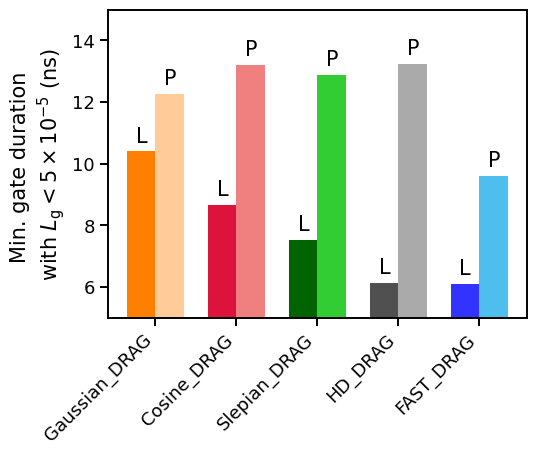

In [2]:
light_blue = [0.3010, 0.7450, 0.9330]
dark_blue = [51/255,51/255,255/255]
crimson = [220/255, 20/255, 60/255] 
light_red = [240/255,128/255,128/255]
light_green = [50/255,205/255,50/255]
dark_green = [0/255,100/255,0/255]
dark_orange = [255/255, 128/255, 0]
light_orange = [255/255, 204/255, 153/255]
dark_gray = [80/255, 80/255, 80/255] 
light_gray = [170/255, 170/255, 170/255]
colors_dict = {'FAST_DRAG-L': dark_blue, 'FAST_DRAG-P': light_blue,  
               'Cosine_DRAG-L': crimson, 'Cosine_DRAG-P': light_red,  
               'HD_DRAG-L': dark_gray, 'HD_DRAG-P': light_gray,
               'Slepian_DRAG-L': dark_green, 'Slepian_DRAG-P': light_green,
               'Gaussian_DRAG-L': dark_orange, 'Gaussian_DRAG-P': light_orange,
              }


#Re-read csv-files and plot
file = open("pulse_shapes_mat.csv", "r")
pulse_shapes_mat = list(csv.reader(file, delimiter=","))
file.close()
min_tg_with_leakage_below_threshold_mat = np.genfromtxt('min_tg_with_leakage_below_threshold_mat.csv', delimiter=',', dtype=None)

width = 0.35  # the width of the bars
x = np.arange(len(pulse_shapes_mat[0]))
leakage_thres = 5e-5

pulse_names_for_xlabel = [pulse[:-2] for pulse in  pulse_shapes_mat[0]]

fig, ax = plt.subplots(1, 1, figsize=(5.4,4))
for idx_pulse in range(len(pulse_shapes_mat[0])):
    for idx_drag_type in range(2):
        x_loc = x[idx_pulse] - width/2 + idx_drag_type * width
        min_tg_below_leak_thres = min_tg_with_leakage_below_threshold_mat[idx_drag_type][len(pulse_shapes_mat[0])-idx_pulse-1]
        label = 'L' if idx_drag_type == 0 else 'P'
        pulse_shape = pulse_shapes_mat[idx_drag_type][len(pulse_shapes_mat[0])-idx_pulse-1]
        rects = ax.bar([x_loc], [min_tg_below_leak_thres], width, color=colors_dict[pulse_shape])
        ax.text(x_loc-0.07, min_tg_below_leak_thres+0.3, label, {'color': 'k', 'fontsize': 15})

base10_exponent = int(np.floor(np.log10(leakage_thres)))
mult_factor = leakage_thres / 10 ** base10_exponent
ax.set_ylabel('Min. gate duration \n' + r'with $L_\mathrm{g}<%.0f \times 10^{%d}$ (ns)'%(mult_factor, base10_exponent), fontsize=15)
ax.set_xticks(x, reversed(pulse_names_for_xlabel), rotation=45, ha='right', fontsize=15)
ax.set_ylim(5, 15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)